In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Load preprocessed data
X_train = joblib.load('../models/X_train.pkl')
X_val = joblib.load('../models/X_val.pkl')
X_test = joblib.load('../models/X_test.pkl')
y_train = joblib.load('../models/y_train.pkl')
y_val = joblib.load('../models/y_val.pkl')
y_test = joblib.load('../models/y_test.pkl')
feature_names = joblib.load('../models/feature_names.pkl')
label_encoder = joblib.load('../models/label_encoder.pkl')

print("Data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nFeature names: {feature_names}")

Data loaded successfully!
X_train shape: (69991, 10)
X_val shape: (14998, 10)
X_test shape: (14999, 10)

Feature names: ['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'red_shift', 'u-g', 'g-r', 'r-i', 'i-z']


In [2]:
# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,  # Number of trees
    max_depth=10,      # Limit tree depth to prevent overfitting
    random_state=42,
    n_jobs=-1          # Use all CPU cores
)

# Train the model
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# Predict on validation set
y_pred_val = rf_model.predict(X_val)

# Calculate accuracy
val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"\n✅ Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

# Classification report
print("\n📊 Classification Report (Validation Set):")
print(classification_report(y_val, y_pred_val, 
                           target_names=label_encoder.classes_))

Training Random Forest...

✅ Validation Accuracy: 0.9787 (97.87%)

📊 Classification Report (Validation Set):
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98      8915
         QSO       0.97      0.94      0.95      2844
        STAR       0.99      1.00      0.99      3239

    accuracy                           0.98     14998
   macro avg       0.98      0.97      0.98     14998
weighted avg       0.98      0.98      0.98     14998



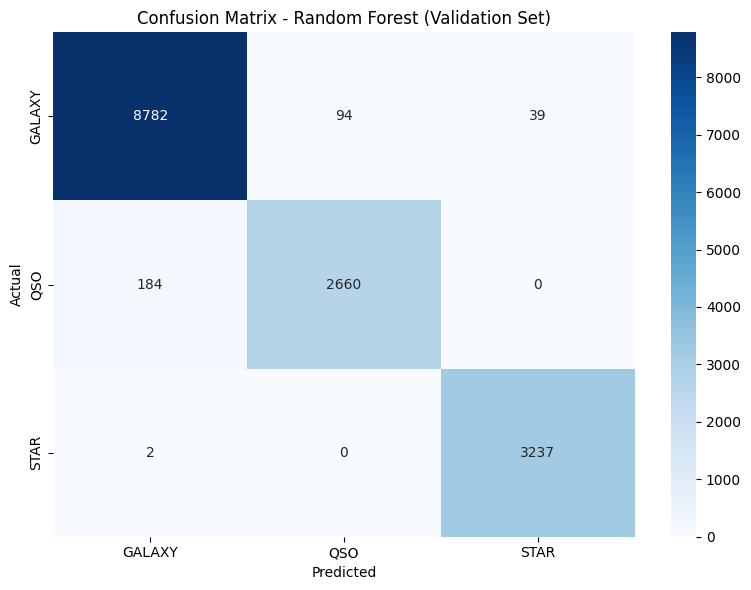

✅ Confusion matrix saved to visualizations/


In [3]:
# Create confusion matrix
cm = confusion_matrix(y_val, y_pred_val)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (Validation Set)')
plt.tight_layout()
plt.savefig('../visualizations/rf_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved to visualizations/")

🔝 Top 5 Most Important Features:
          feature  importance
5       red_shift    0.546897
7             g-r    0.130586
8             r-i    0.113706
6             u-g    0.046601
9             i-z    0.043620
4       IR_filter    0.033695
1    green_filter    0.030151
2      red_filter    0.021712
3  near_IR_filter    0.018197
0       UV_filter    0.014835


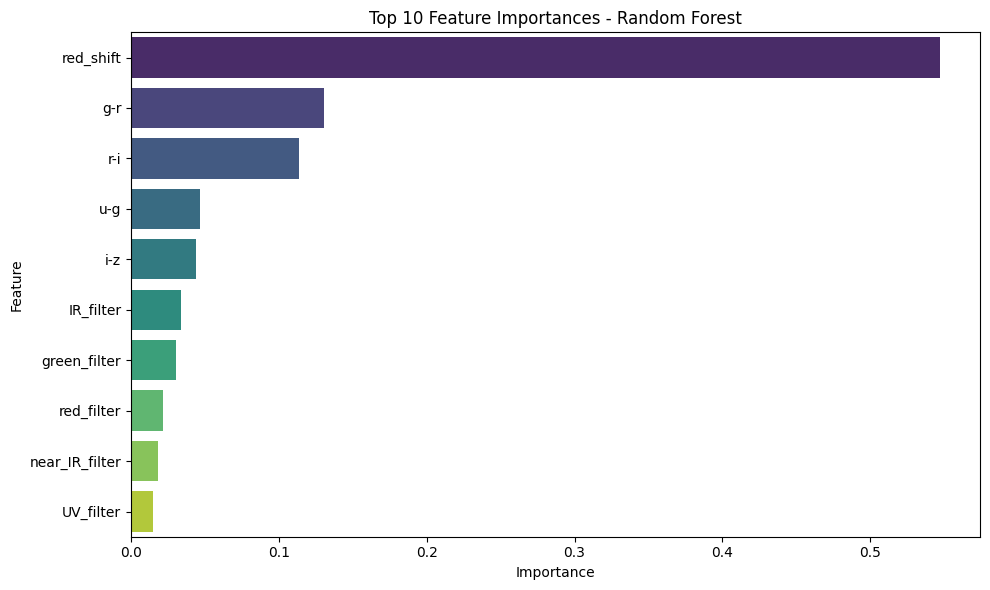

✅ Feature importance plot saved to visualizations/


In [4]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("🔝 Top 5 Most Important Features:")
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances - Random Forest')
plt.tight_layout()
plt.savefig('../visualizations/rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature importance plot saved to visualizations/")

In [5]:
# Predict on test set (unseen data)
y_pred_test = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f" Test Set Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\n Detailed Test Set Performance:")
print(classification_report(y_test, y_pred_test, 
                           target_names=label_encoder.classes_))

# Save the model
joblib.dump(rf_model, '../models/random_forest_baseline.pkl')
print("\n✅ Model saved as '../models/random_forest_baseline.pkl'")

 Test Set Accuracy: 0.9782 (97.82%)

 Detailed Test Set Performance:
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98      8916
         QSO       0.96      0.94      0.95      2844
        STAR       0.99      1.00      0.99      3239

    accuracy                           0.98     14999
   macro avg       0.98      0.97      0.97     14999
weighted avg       0.98      0.98      0.98     14999


✅ Model saved as '../models/random_forest_baseline.pkl'


In [7]:
# Find misclassified examples
y_test_pred = rf_model.predict(X_test)
misclassified = np.where(y_test != y_test_pred)[0]

print(f"Total misclassified: {len(misclassified)} out of {len(y_test)}")
print(f"Misclassification rate: {len(misclassified)/len(y_test)*100:.2f}%")

# Show a few examples
print("\n Sample Misclassifications (Actual → Predicted):")
for i in range(min(5, len(misclassified))):
    idx = misclassified[i]
    actual = label_encoder.inverse_transform([y_test[idx]])[0]
    predicted = label_encoder.inverse_transform([y_test_pred[idx]])[0]
    print(f"  {actual} → {predicted}")

Total misclassified: 327 out of 14999
Misclassification rate: 2.18%

 Sample Misclassifications (Actual → Predicted):
  QSO → GALAXY
  GALAXY → QSO
  QSO → GALAXY
  QSO → GALAXY
  GALAXY → STAR


In [8]:
# Create summary DataFrame
baseline_results = pd.DataFrame({
    'Metric': ['Validation Accuracy', 'Test Accuracy', 'Misclassification Rate',
               'GALAXY F1', 'QSO F1', 'STAR F1'],
    'Value': [0.9787, 0.9782, 0.0218, 0.98, 0.95, 0.99]
})

# Save
baseline_results.to_csv('../models/baseline_results.csv', index=False)
print("✅ Baseline results saved to models/baseline_results.csv")

# Feature importance summary
feature_importance.to_csv('../models/feature_importance.csv', index=False)
print("✅ Feature importance saved to models/feature_importance.csv")

✅ Baseline results saved to models/baseline_results.csv
✅ Feature importance saved to models/feature_importance.csv
